In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## Inspecting The Data & Data Information

In [2]:
species_df = pd.read_csv('species_info.csv')

observation_df = pd.read_csv('observations.csv')

In [3]:
print(species_df.head()) # Understanding the data, all columns are accounted for
print(species_df.dtypes)

print(observation_df.head())
print(observation_df.dtypes)

  category                scientific_name  \
0   Mammal  Clethrionomys gapperi gapperi   
1   Mammal                      Bos bison   
2   Mammal                     Bos taurus   
3   Mammal                     Ovis aries   
4   Mammal                 Cervus elaphus   

                                        common_names conservation_status  
0                           Gapper's Red-Backed Vole                 NaN  
1                              American Bison, Bison                 NaN  
2  Aurochs, Aurochs, Domestic Cattle (Feral), Dom...                 NaN  
3  Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)                 NaN  
4                                      Wapiti Or Elk                 NaN  
category               object
scientific_name        object
common_names           object
conservation_status    object
dtype: object
            scientific_name                            park_name  observations
0        Vicia benghalensis  Great Smoky Mountains National Park  

In [4]:
print(species_df.info())
print(species_df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5824 entries, 0 to 5823
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   category             5824 non-null   object
 1   scientific_name      5824 non-null   object
 2   common_names         5824 non-null   object
 3   conservation_status  191 non-null    object
dtypes: object(4)
memory usage: 182.1+ KB
None
              category scientific_name        common_names conservation_status
count             5824            5824                5824                 191
unique               7            5541                5504                   4
top     Vascular Plant   Procyon lotor  Brachythecium Moss  Species of Concern
freq              4470               3                   7                 161


## Inspecting Missing Data & Understanding Columns Further

In [5]:
print(species_df.conservation_status.unique())
species_df[species_df.isnull().any(axis=1)] # Null values in conservation_status means that the species who are Null do not need a conseravtion status (free from concerns, endangerment, etc.)

[nan 'Species of Concern' 'Endangered' 'Threatened' 'In Recovery']


,category,scientific_name,common_names,conservation_status
0,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,NaN
1,Mammal,Bos bison,"American Bison, Bison",NaN
2,Mammal,Bos taurus,"Aurochs, Aurochs, Domestic Cattle (Feral), Dom...",NaN
3,Mammal,Ovis aries,"Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)",NaN
4,Mammal,Cervus elaphus,Wapiti Or Elk,NaN
...,...,...,...,...
5819,Vascular Plant,Solanum parishii,Parish's Nightshade,NaN
5820,Vascular Plant,Solanum xanti,"Chaparral Nightshade, Purple Nightshade",NaN
5821,Vascular Plant,Parthenocissus vitacea,"Thicket Creeper, Virginia Creeper, Woodbine",NaN
5822,Vascular Plant,Vitis californica,"California Grape, California Wild Grape",NaN


In [6]:
print(observation_df.info()) # All data is accounted for

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23296 entries, 0 to 23295
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   scientific_name  23296 non-null  object
 1   park_name        23296 non-null  object
 2   observations     23296 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 546.1+ KB
None


## Joining Dataframes

In [7]:
merged_df = pd.merge(
    species_df,
    observation_df,
    on='scientific_name',
    how='left'
)

print(merged_df.head()) # Making sure the output is correct
print(merged_df.dtypes)

  category                scientific_name              common_names  \
0   Mammal  Clethrionomys gapperi gapperi  Gapper's Red-Backed Vole   
1   Mammal  Clethrionomys gapperi gapperi  Gapper's Red-Backed Vole   
2   Mammal  Clethrionomys gapperi gapperi  Gapper's Red-Backed Vole   
3   Mammal  Clethrionomys gapperi gapperi  Gapper's Red-Backed Vole   
4   Mammal                      Bos bison     American Bison, Bison   

  conservation_status                            park_name  observations  
0                 NaN                  Bryce National Park           130  
1                 NaN            Yellowstone National Park           270  
2                 NaN  Great Smoky Mountains National Park            98  
3                 NaN               Yosemite National Park           117  
4                 NaN               Yosemite National Park           128  
category               object
scientific_name        object
common_names           object
conservation_status    object
par

## Extracting Data Insights

* What is the spread of recorded observations?  Range of data is 312
* What is the spread of conservation status?  Percentages below. Most percents are on 'Species of Concern'
* How many total observations is there?  3,645,247 Species observations
* How many categories is there?  7 Categories
* How many scientific names is there?  5,541 names
* What is the mean observations across all species?  On average 142.21 observations

In [8]:
all_categories = merged_df.category.unique()
print(all_categories)

['Mammal' 'Bird' 'Reptile' 'Amphibian' 'Fish' 'Vascular Plant'
 'Nonvascular Plant']


In [9]:
all_names = merged_df.scientific_name.nunique()
print(all_names) # Just to confirm

5541


In [10]:
grouped_conservation = merged_df.groupby('conservation_status')['observations'].sum()
print(grouped_conservation)

conservation_status
Endangered             3513
In Recovery            2107
Species of Concern    93962
Threatened             3339
Name: observations, dtype: int64


In [11]:
print(grouped_conservation.sum()) # Note the output does not reflect the true amount of observations recorded in the csv, only a partial amount

102921


In [12]:
print(merged_df.conservation_status.value_counts(normalize=True)) # Just to see the percentages

conservation_status
Species of Concern    0.831818
Endangered            0.090909
Threatened            0.050000
In Recovery           0.027273
Name: proportion, dtype: float64


In [13]:
grouped_parks = merged_df.groupby('park_name')['observations'].sum()
print(grouped_parks)

park_name
Bryce National Park                     633291
Great Smoky Mountains National Park     474863
Yellowstone National Park              1587641
Yosemite National Park                  949452
Name: observations, dtype: int64


In [14]:
print(grouped_parks.sum())

3645247


In [15]:
print(merged_df.observations.min())
print(merged_df.observations.max())

observation_range = merged_df.observations.max() - merged_df.observations.min()
print(observation_range) # Range of data

9
321
312


In [16]:
print(grouped_parks.mean()) # Per park on average 911,311.75 observations
print(grouped_conservation.mean()) # Per conservation status 25,730.25 observations, 'Species of Concern' is a heavy outlier which skews the data
print(merged_df.observations.mean()) # Across all species on average 142.21 observations

911311.75
25730.25
142.21469257178526


In [17]:
mean_observations = merged_df.groupby('conservation_status')['observations'].mean()

print(mean_observations)

conservation_status
Endangered             43.912500
In Recovery            87.791667
Species of Concern    128.363388
Threatened             75.886364
Name: observations, dtype: float64


In [18]:
# ^Average obeservation per species within each conservation status

In [19]:
park_species = merged_df.groupby('park_name')['scientific_name'].nunique()

print(park_species) #To see if any park had a unique number of species comapared to the others

park_name
Bryce National Park                    5541
Great Smoky Mountains National Park    5541
Yellowstone National Park              5541
Yosemite National Park                 5541
Name: scientific_name, dtype: int64


In [20]:
at_risk = ['Species of Concern','Endangered', 'In Recovery', 'Threatened']

merged_df['is_at_risk'] = merged_df['conservation_status'].isin(at_risk)

at_risk_species = (
    merged_df[merged_df['is_at_risk']]
    .groupby('park_name')['scientific_name']
    .nunique()
)

park_risk = (at_risk_species / park_species).sort_values()
print(park_risk) # These values show that the data question I was trying to answer. Though is not what I wanted to extract. So I'll ask a different question, yet want to keep this code here as a reminder.   

park_name
Bryce National Park                    0.032305
Great Smoky Mountains National Park    0.032305
Yellowstone National Park              0.032305
Yosemite National Park                 0.032305
Name: scientific_name, dtype: float64


In [21]:
endangered_species = merged_df[merged_df['conservation_status'].str.strip().str.lower() == 'endangered'] # ensuring no case issues

print(endangered_species)

print(len(endangered_species)) # There is 80 rows endanered species 

        category          scientific_name                      common_names  \
44        Mammal              Canis lupus                         Gray Wolf   
45        Mammal              Canis lupus                         Gray Wolf   
46        Mammal              Canis lupus                         Gray Wolf   
47        Mammal              Canis lupus                         Gray Wolf   
48        Mammal              Canis lupus                         Gray Wolf   
...          ...                      ...                               ...   
20007       Bird  Gymnogyps californianus                 California Condor   
20460  Amphibian             Rana sierrae  Sierra Nevada Yellow-Legged Frog   
20461  Amphibian             Rana sierrae  Sierra Nevada Yellow-Legged Frog   
20462  Amphibian             Rana sierrae  Sierra Nevada Yellow-Legged Frog   
20463  Amphibian             Rana sierrae  Sierra Nevada Yellow-Legged Frog   

      conservation_status                          

In [22]:
total_by_category = species_df.groupby('category')['scientific_name'].nunique()

endangered_by_category = (
    species_df[species_df['conservation_status'] == 'Endangered'] # Kept the uppercase 'E' because upon csv inspection that was used strictly. 
    .groupby('category')['scientific_name']
    .nunique()
)

endangered_ratio = (endangered_by_category / total_by_category).sort_values().fillna(0)


print(endangered_ratio)

category
Vascular Plant       0.000235
Bird                 0.008197
Amphibian            0.012658
Fish                 0.024000
Mammal               0.034091
Nonvascular Plant    0.000000
Reptile              0.000000
Name: scientific_name, dtype: float64


In [23]:
at_risk_obs = (
    merged_df[merged_df['is_at_risk']]
    .groupby('park_name')['observations']
    .sum()
)

park_risk_obs_ratio = (at_risk_obs / grouped_parks).sort_values()

print(park_risk_obs_ratio) # This question is more along the lines of park at-risk observation intensity. It still shows which park is potentially more dangerous, yet statictically soundly so. 

park_name
Great Smoky Mountains National Park    0.026989
Yellowstone National Park              0.028081
Yosemite National Park                 0.028346
Bryce National Park                    0.029385
Name: observations, dtype: float64


## Data Visualizations

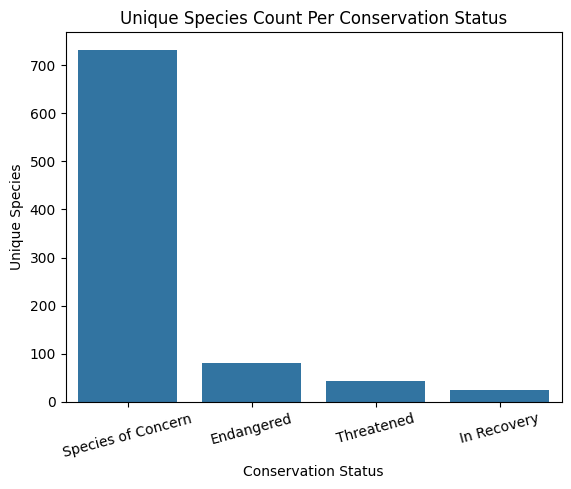

<Figure size 640x480 with 0 Axes>

In [24]:
sns.countplot(data=merged_df, x='conservation_status')
plt.xlabel('Conservation Status')
plt.xticks(rotation=15, fontsize=10)
plt.ylabel('Unique Species')
plt.title('Unique Species Count Per Conservation Status')

plt.savefig('Biodiversity_Unique.png', dpi=300, bbox_inches='tight')
plt.show()
plt.clf()


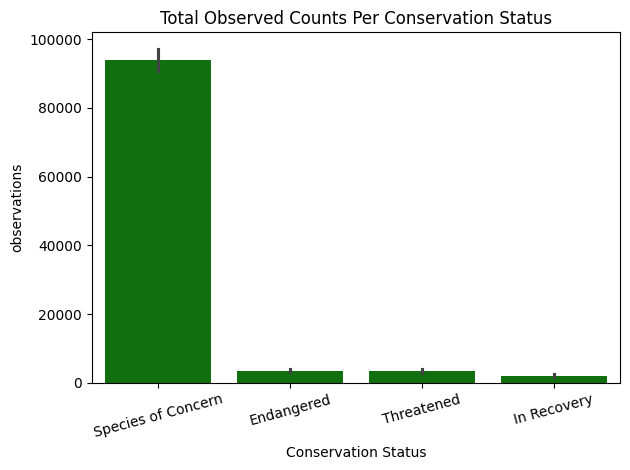

<Figure size 640x480 with 0 Axes>

In [25]:
sns.barplot(
    data = merged_df,
    x = 'conservation_status',
    y = 'observations', 
    estimator=sum,
    color='green'
)
plt.xticks(rotation=15)
plt.xlabel('Conservation Status')
plt.title('Total Observed Counts Per Conservation Status')
plt.tight_layout()

plt.savefig('Biodiversity_Total.png', dpi=300, bbox_inches='tight')
plt.show()
plt.clf()

In [26]:
# We can clearly see that there is a large porportion of life that is not endangered, yet endangered has more counts amongst the last two columns.

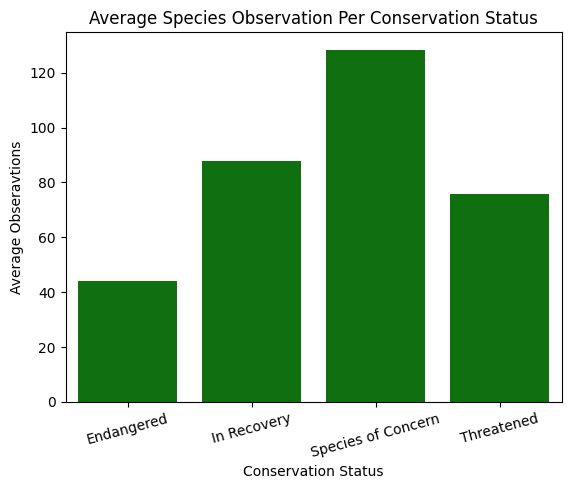

<Figure size 640x480 with 0 Axes>

In [27]:
sns.barplot(
    x=mean_observations.index,
    y=mean_observations.values,
    color='green'
)

plt.xticks(rotation=15)
plt.xlabel('Conservation Status')
plt.ylabel('Average Obseravtions')
plt.title('Average Species Observation Per Conservation Status')

plt.savefig('Biodiversity_Average.png', dpi=300, bbox_inches='tight')
plt.show()
plt.clf()

In [28]:
# Despite endangered having a higher .sum() value than 2 columns, endangered species on average are spotted less often. That metric aligns with their status of being endangered. 

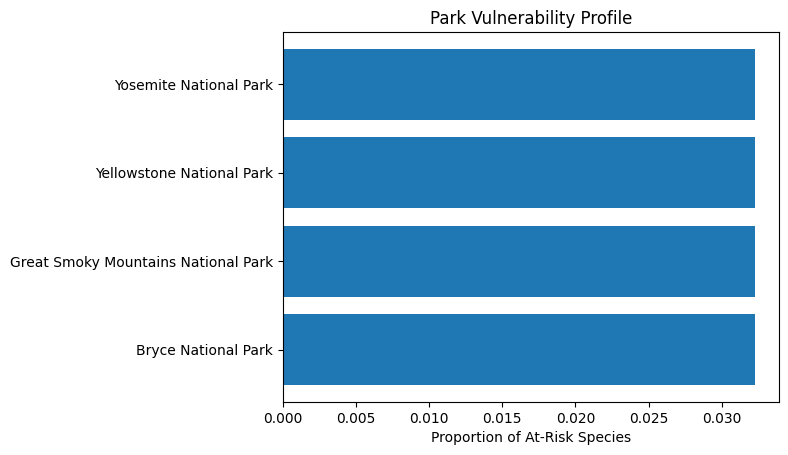

<Figure size 640x480 with 0 Axes>

In [29]:
plt.figure() # This plot was an attempt to plot park risk though the data and visualization did not answer the question clearly. Yet, I'm leaving it in the code just as a reminder and to be transparent. 
plt.barh(park_risk.index, park_risk.values)
plt.xlabel('Proportion of At-Risk Species')
plt.title('Park Vulnerability Profile')
plt.show()
plt.clf()

